In [1]:

import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [2]:
IMAGE_SIZE= 256
BATCH_SIZE=15
CHANNELS=3
EPOCHS=50

In [3]:
import os


DATASET_DIR = os.path.normpath(os.path.join(os.getcwd(), "..", "PlantVillage"))
print(f"Dataset path: {DATASET_DIR}")

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Dataset path: c:\Users\HP\Plant-Disease-Detection\PlantVillage
Found 2152 files belonging to 3 classes.


In [4]:
# Image Data Augmentation Generator
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    featurewise_center=False,
    samplewise_center=False,
    featurewise_std_normalization=False,
    samplewise_std_normalization=False,
    zca_whitening=False,
    zca_epsilon=1e-06,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    shear_range=0.2,
    zoom_range=0.2,
    channel_shift_range=0.0,
    fill_mode='nearest',
    cval=0.0,
    horizontal_flip=True,
    vertical_flip=False,
    rescale=1./255,
    preprocessing_function=None,
    data_format=None,
    validation_split=0.2,
    interpolation_order=1,
    dtype=None
)

# Validation generator (only rescaling, no augmentation)
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

import os
DATASET_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'PlantVillage'))

train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    shuffle=False,
    seed=42
)

print(f'Training samples  : {train_generator.samples}')
print(f'Validation samples: {val_generator.samples}')
print(f'Classes           : {list(train_generator.class_indices.keys())}')

Found 1722 images belonging to 3 classes.
Found 430 images belonging to 3 classes.
Training samples  : 1722
Validation samples: 430
Classes           : ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [5]:
# NOTE: Normalization is already handled by ImageDataGenerator (rescale=1./255)
# Therefore, this manual normalization step is not needed and train_ds is undefined.

# def process(image, label):
#     image=tf.cast(image/255. , tf.float32)
#     return image,label

# train_ds=train_ds.map(process)
# validation_ds=validation_ds.map(process)

In [ ]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(3,activation='softmax'))


c:\Users\HP\Plant-Disease-Detection\.venv311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [8]:
history = model.fit(train_generator, epochs=10, validation_data=val_generator)



Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 86s 711ms/step - accuracy: 0.6614 - loss: 0.8311 - val_accuracy: 0.8698 - val_loss: 0.3404
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 82s 710ms/step - accuracy: 0.8531 - loss: 0.3749 - val_accuracy: 0.8698 - val_loss: 0.3602
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 78s 678ms/step - accuracy: 0.8931 - loss: 0.2661 - val_accuracy: 0.8535 - val_loss: 0.4551
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 75s 656ms/step - accuracy: 0.9170 - loss: 0.2238 - val_accuracy: 0.8674 - val_loss: 0.3229
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 72s 624ms/step - accuracy: 0.9129 - loss: 0.2300 - val_accuracy: 0.8814 - val_loss: 0.2978
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 83s 720ms/step - accuracy: 0.9228 - loss: 0.1935 - val_accuracy: 0.9395 - val_loss: 0.1524
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 77s 668ms/step - accuracy: 0.9233 - loss: 0.2003 - val_accuracy: 0.9209 - val_loss: 0.2008
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 77s 671ms/step - accuracy: 0.9303 - loss: 0

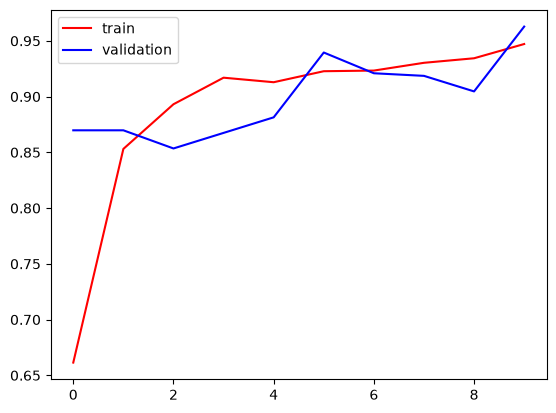

In [9]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color='red',label='train')
plt.plot(history.history['val_accuracy'], color='blue',label='validation')
plt.legend()
plt.show()

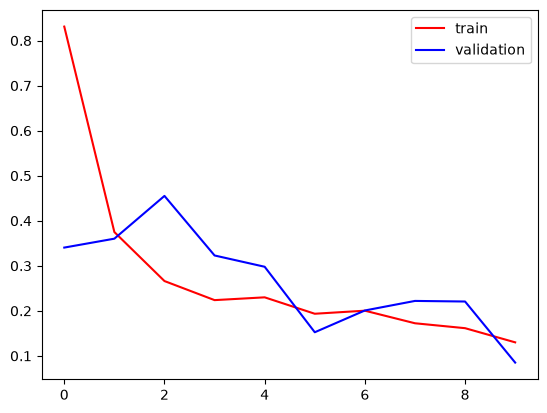

In [10]:
plt.plot(history.history['loss'], color='red',label='train')
plt.plot(history.history['val_loss'], color='blue',label='validation')
plt.legend()
plt.show()

In [13]:
import os

model_version = 1
os.makedirs("../models", exist_ok=True)
model.save(f"../models/{model_version}.keras")
